In [91]:
import pandas as pd
df = pd.read_csv("..\\data\\student-course-completion-prediction-dataset-trimmed.csv")

print(df.shape)
print(df.head())

print(df.dtypes.to_frame(name="dtype"))

(30001, 40)
  Student_ID             Name  Gender  Age Education_Level Employment_Status  \
0  STU100000     Vihaan Patel    Male   19         Diploma           Student   
1  STU100000     Vihaan Patel    Male   19         Diploma           Student   
2  STU100001       Arjun Nair  Female  170        Bachelor           Student   
3  STU100002  Aditya Bhardwaj  Female   34          Master           Student   
4  STU100003    Krishna Singh  Female   29         Diploma          Employed   

      City Device_Type Internet_Connection_Quality Course_ID  ...  \
0   Indore      Laptop                      Medium      C102  ...   
1   Indore      Laptop                      Medium      C102  ...   
2    Delhi      Laptop                         Low      C106  ...   
3  Chennai      Mobile                      Medium      C101  ...   
4    Surat      Mobile                        High      C105  ...   

  Enrollment_Date Payment_Mode Fee_Paid  Discount_Used  Payment_Amount  \
0       1/06/2024 

In [92]:
# Keep an untouched copy of the loaded and named dataset
df_copy = df.copy(deep=True)

In [93]:
# Check missing values
missing = df_copy.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False))

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df_copy.duplicated().sum())

# Check the ranges of important measurements
range_cols = [
    "Age", 
    "Course_Duration_Days", 
    "Average_Session_Duration_Min", 
    "Video_Completion_Rate", 
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Quiz_Score_Avg", 
    "Project_Grade", 
    "Progress_Percentage" 
]

print("\nMinimum and maximum values:")
print(df_copy[range_cols].agg(["min", "max"]))

Columns containing missing values:
Series([], dtype: int64)

Number of duplicate rows:
1

Minimum and maximum values:
     Age  Course_Duration_Days  Average_Session_Duration_Min  \
min   17                    25                             5   
max  170                    90                            76   

     Video_Completion_Rate  Time_Spent_Hours  Days_Since_Last_Login  \
min                    5.0               0.5                      0   
max                   99.9              25.6                     99   

     Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  \
min                      0                   0              0            19.6   
max                     10                  10             16           100.0   

     Project_Grade  Progress_Percentage  
min            6.8                  9.7  
max          100.0                 97.4  


In [94]:
review_cols = [
    "Age", # improbable to have students younger than 10 or older than 90
    "Course_Duration_Days", # 0 <= result <= 90
    "Average_Session_Duration_Min", # 0 <= result <= 80
    "Video_Completion_Rate", # 0 <= result <= 100
    "Time_Spent_Hours", # 0 <= result <= 30
    "Days_Since_Last_Login", # 0 <= result <= 100
    "Assignments_Submitted", # submitted + missed assignments total should not exceed 10
    "Assignments_Missed", # submitted + missed assignments total should not exceed 10 
    "Quiz_Attempts", # 0 <= result <= 16
    "Quiz_Score_Avg", # 0 <= result <= 100
    "Project_Grade", # 0 <= result <= 100
    "Progress_Percentage" # 0 <= result <= 100
]

records_to_review = df_copy.loc[
    ((df_copy["Age"] < 10) | (df_copy["Age"] > 90)) |
    ((df_copy["Course_Duration_Days"] < 0) | (df_copy["Course_Duration_Days"] > 90)) |
    ((df_copy["Average_Session_Duration_Min"] < 0) | (df_copy["Average_Session_Duration_Min"] > 80)) |
    ((df_copy["Video_Completion_Rate"] < 0) | (df_copy["Video_Completion_Rate"] > 100)) |
    ((df_copy["Time_Spent_Hours"] < 0) | (df_copy["Time_Spent_Hours"] > 30)) |
    ((df_copy["Days_Since_Last_Login"] < 0) | (df_copy["Days_Since_Last_Login"] > 100)) |
    ((df_copy["Assignments_Submitted"] < 0) | (df_copy["Assignments_Submitted"] > 10)) |
    ((df_copy["Assignments_Missed"] < 0) | (df_copy["Assignments_Missed"] > 10)) |
    ((df_copy["Quiz_Attempts"] < 0) | (df_copy["Quiz_Attempts"] > 16)) |
    ((df_copy["Quiz_Score_Avg"] < 0) | (df_copy ["Quiz_Score_Avg"] > 100)) |
    ((df_copy["Project_Grade"] < 0) | (df_copy["Project_Grade"] > 100)) |
    ((df_copy["Progress_Percentage"] < 0) | (df_copy["Progress_Percentage"] > 100))
].sort_values(
    ["Age", "Course_Duration_Days", "Average_Session_Duration_Min"]
)

print(records_to_review.to_string())

  Student_ID        Name  Gender  Age Education_Level Employment_Status   City Device_Type Internet_Connection_Quality Course_ID           Course_Name     Category Course_Level  Course_Duration_Days  Instructor_Rating  Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  Discussion_Participation  Time_Spent_Hours  Days_Since_Last_Login  Notifications_Checked  Peer_Interaction_Score  Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  Project_Grade  Progress_Percentage  Rewatch_Count Enrollment_Date Payment_Mode Fee_Paid Discount_Used  Payment_Amount  App_Usage_Percentage  Reminder_Emails_Clicked  Support_Tickets_Raised  Satisfaction_Rating      Completed
2  STU100001  Arjun Nair  Female  170        Bachelor           Student  Delhi      Laptop                         Low      C106  Machine Learning A-Z  Programming     Advanced                    90                4.6                4                            37                   84.1           

In [95]:
# Clean a copy of the dataset without changing the original
def clean_data(data):
    # Create a copy so the original data stays unchanged
    clean = data.copy(deep=True)

    # Correct the confirmed age error for STU100001
    # The original dataset shows age 17, not 170
    clean.loc[
        clean["Student_ID"] == "STU100001",
        "Age"
    ] = 17

    for col in [
        "Quiz_Score_Avg",
        "Project_Grade",
        "Progress_Percentage",
        "App_Usage_Percentage"
    ]:
        clean[col] = clean[col].fillna(clean[col].median())

    clean = clean.drop_duplicates()
    clean = clean.reset_index(drop=True)

    return clean

In [96]:
# Apply the cleaning function to the untouched dataset
df_clean_preview = clean_data(df_copy)

In [97]:
# Check what type of object records_to_review is
# This helps us understand why it cannot be used directly as a row filter
print(type(records_to_review))

# Show its size
print(records_to_review.shape)

<class 'pandas.DataFrame'>
(1, 40)


In [98]:
# Display the record that was flagged for review
# We want to confirm exactly which student is inside records_to_review
records_to_review[
    ["Student_ID", "Name", "Age"]
]

,Student_ID,Name,Age
2,STU100001,Arjun Nair,170


In [99]:
print("Original shape:", df_copy.shape)
print("Cleaned shape:", df_clean_preview.shape)

print(
    "Rows removed:",
    len(df_copy) - len(df_clean_preview)
)

Original shape: (30001, 40)
Cleaned shape: (30000, 40)
Rows removed: 1


In [100]:
range_cols = [
    "Age", 
    "Course_Duration_Days", 
    "Average_Session_Duration_Min", 
    "Video_Completion_Rate", 
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Quiz_Score_Avg", 
    "Project_Grade", 
    "Progress_Percentage" 
]

print("\nMinimum and maximum values:")
print(df_copy[range_cols].agg(["min", "max"]))


Minimum and maximum values:
     Age  Course_Duration_Days  Average_Session_Duration_Min  \
min   17                    25                             5   
max  170                    90                            76   

     Video_Completion_Rate  Time_Spent_Hours  Days_Since_Last_Login  \
min                    5.0               0.5                      0   
max                   99.9              25.6                     99   

     Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  \
min                      0                   0              0            19.6   
max                     10                  10             16           100.0   

     Project_Grade  Progress_Percentage  
min            6.8                  9.7  
max          100.0                 97.4  


In [101]:
invalid_record = (
        ((df_clean_preview["Age"] < 10) | (df_clean_preview["Age"] > 90)) |
        ((df_clean_preview["Course_Duration_Days"] < 0) | (df_clean_preview["Course_Duration_Days"] > 90)) |
        ((df_clean_preview["Average_Session_Duration_Min"] < 0) | (df_clean_preview["Average_Session_Duration_Min"] > 80)) |
        ((df_clean_preview["Video_Completion_Rate"] < 0) | (df_clean_preview["Video_Completion_Rate"] > 100)) |
        ((df_clean_preview["Time_Spent_Hours"] < 0) | (df_clean_preview["Time_Spent_Hours"] > 30)) |
        ((df_clean_preview["Days_Since_Last_Login"] < 0) | (df_clean_preview["Days_Since_Last_Login"] > 100)) |
        ((df_clean_preview["Assignments_Submitted"] < 0) | (df_clean_preview["Assignments_Submitted"] > 10)) |
        ((df_clean_preview["Assignments_Missed"] < 0) | (df_clean_preview["Assignments_Missed"] > 10)) |
        ((df_clean_preview["Quiz_Attempts"] < 0) | (df_clean_preview["Quiz_Attempts"] > 16)) |
        ((df_clean_preview["Quiz_Score_Avg"] < 0) | (df_clean_preview["Quiz_Score_Avg"] > 100)) |
        ((df_clean_preview["Project_Grade"] < 0) | (df_clean_preview["Project_Grade"] > 100)) |
        ((df_clean_preview["Progress_Percentage"] < 0) | (df_clean_preview["Progress_Percentage"] > 100))
    )

print(df_clean_preview.loc[invalid_record].to_string())

Empty DataFrame
Columns: [Student_ID, Name, Gender, Age, Education_Level, Employment_Status, City, Device_Type, Internet_Connection_Quality, Course_ID, Course_Name, Category, Course_Level, Course_Duration_Days, Instructor_Rating, Login_Frequency, Average_Session_Duration_Min, Video_Completion_Rate, Discussion_Participation, Time_Spent_Hours, Days_Since_Last_Login, Notifications_Checked, Peer_Interaction_Score, Assignments_Submitted, Assignments_Missed, Quiz_Attempts, Quiz_Score_Avg, Project_Grade, Progress_Percentage, Rewatch_Count, Enrollment_Date, Payment_Mode, Fee_Paid, Discount_Used, Payment_Amount, App_Usage_Percentage, Reminder_Emails_Clicked, Support_Tickets_Raised, Satisfaction_Rating, Completed]
Index: []


In [102]:
missing = df_clean_preview.isna().sum()
print("\nColumns still containing missing values:")
print(
    missing[missing > 0]
    .sort_values(ascending=False)
)
print(
    "\nDuplicate rows:",
    df_clean_preview.duplicated().sum()
)


Columns still containing missing values:
Series([], dtype: int64)

Duplicate rows: 0


In [103]:
print("\nFirst five cleaned records:")
print(
    df_clean_preview[
        [
            "Student_ID",
            "Name",
            "Gender",
            "Age",
            "Education_Level",
            "Employment_Status",
            "Completed"
        ]
    ].head()
)


First five cleaned records:
  Student_ID             Name  Gender  Age Education_Level Employment_Status  \
0  STU100000     Vihaan Patel    Male   19         Diploma           Student   
1  STU100001       Arjun Nair  Female   17        Bachelor           Student   
2  STU100002  Aditya Bhardwaj  Female   34          Master           Student   
3  STU100003    Krishna Singh  Female   29         Diploma          Employed   
4  STU100004     Krishna Nair  Female   19          Master     Self-Employed   

       Completed  
0      Completed  
1  Not Completed  
2      Completed  
3      Completed  
4      Completed  


In [104]:
import sqlite3
# Use the cleaned data already reviewed above
df_etl_clean = df_clean_preview.copy(deep=True)

with sqlite3.connect("..\\data\\etl.db") as conn:
    df_etl_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

print("ETL completed.")
print("Cleaned table shape:", df_etl_clean.shape)

ETL completed.
Cleaned table shape: (30000, 40)


In [105]:
with sqlite3.connect("..\\data\\elt.db") as conn:
    # Load the untouched raw data first
    df_copy.to_sql(
        "raw",
        conn,
        if_exists="replace",
        index=False
    )
    # Read the raw table back into Pandas
    df_elt_raw = pd.read_sql(
        "SELECT * FROM raw",
        conn
    )
    # Transform the data after loading
    df_elt_clean = clean_data(df_elt_raw)
    # Store the cleaned result as a second table
    df_elt_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

print("ELT completed.")
print("Raw table shape:", df_elt_raw.shape)
print("Cleaned table shape:", df_elt_clean.shape)

ELT completed.
Raw table shape: (30001, 40)
Cleaned table shape: (30000, 40)


In [106]:
with sqlite3.connect("..\\data\\etl.db") as conn:
    etl_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        conn
    )
print("Tables in etl.db:")
print(etl_tables)

with sqlite3.connect("..\\data\\elt.db") as conn:
    elt_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        conn
    )
print("\nTables in elt.db:")
print(elt_tables)

Tables in etl.db:
    name
0  clean

Tables in elt.db:
    name
0    raw
1  clean


In [107]:
print(df_copy.shape)
print(df_copy.dtypes.value_counts())
print(df_copy.info())
print(df_copy.describe())

(30001, 40)
str        17
int64      15
float64     8
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    30001 non-null  str    
 1   Name                          30001 non-null  str    
 2   Gender                        30001 non-null  str    
 3   Age                           30001 non-null  int64  
 4   Education_Level               30001 non-null  str    
 5   Employment_Status             30001 non-null  str    
 6   City                          30001 non-null  str    
 7   Device_Type                   30001 non-null  str    
 8   Internet_Connection_Quality   30001 non-null  str    
 9   Course_ID                     30001 non-null  str    
 10  Course_Name                   30001 non-null  str    
 11  Category                      30001 non-null  str 

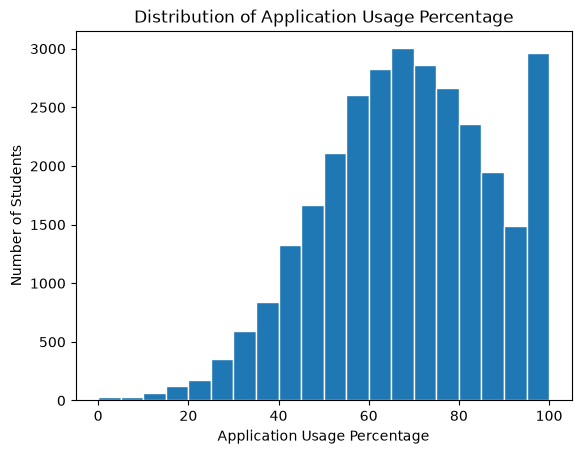

In [108]:
import matplotlib.pyplot as plt

plt.hist(df_etl_clean["App_Usage_Percentage"].dropna(), bins=20, edgecolor="white", linewidth=1)
plt.xlabel("Application Usage Percentage"); plt.ylabel("Number of Students")
plt.title("Distribution of Application Usage Percentage")
plt.show()

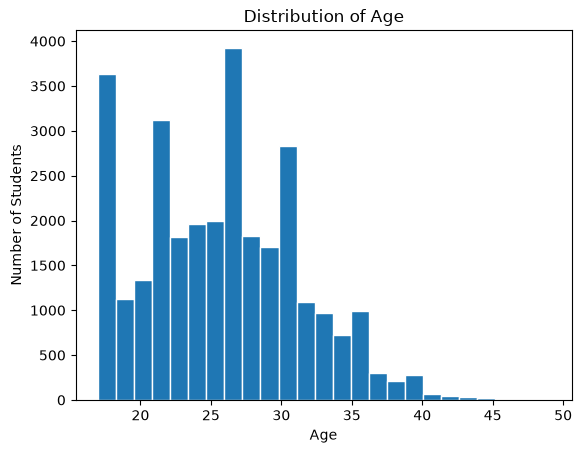

In [109]:
plt.hist(df_etl_clean["Age"].dropna(), bins=25, edgecolor="white", linewidth=1)
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Distribution of Age")
plt.show()

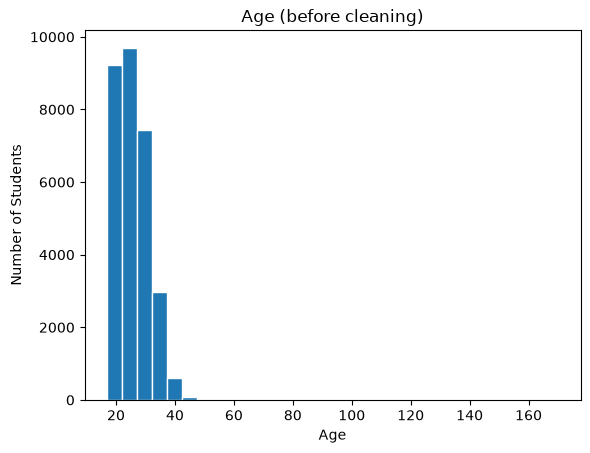

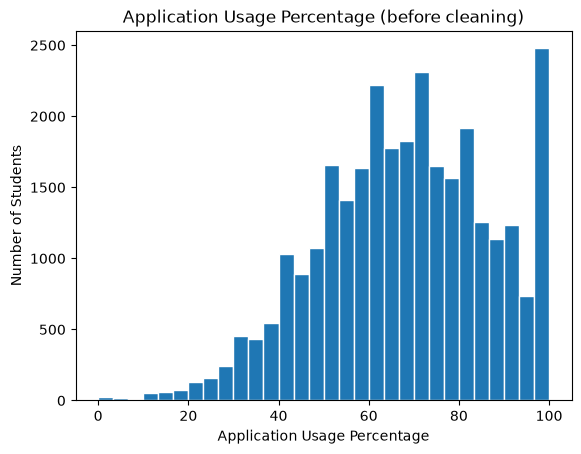

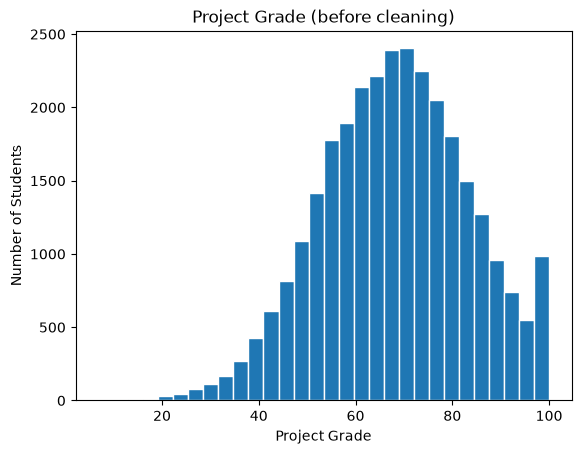

In [110]:
plt.hist(df_copy["Age"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Age (before cleaning)")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()
plt.hist(df_copy["App_Usage_Percentage"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Application Usage Percentage (before cleaning)")
plt.xlabel("Application Usage Percentage")
plt.ylabel("Number of Students")
plt.show()
plt.hist(df_copy["Project_Grade"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Project Grade (before cleaning)")
plt.xlabel("Project Grade")
plt.ylabel("Number of Students")
plt.show()

In [111]:
# Compare the variables that were reviewed during cleaning
for col in ["Age", "Project_Grade", "Quiz_Score_Avg", "Time_Spent_Hours"]:
    print(
        col,
        "raw range:",
        (df_copy[col].min(), df_copy[col].max()),
        "clean range:",
        (df_etl_clean[col].min(), df_etl_clean[col].max())
    )

Age raw range: (np.int64(17), np.int64(170)) clean range: (np.int64(17), np.int64(49))
Project_Grade raw range: (np.float64(6.8), np.float64(100.0)) clean range: (np.float64(6.8), np.float64(100.0))
Quiz_Score_Avg raw range: (np.float64(19.6), np.float64(100.0)) clean range: (np.float64(19.6), np.float64(100.0))
Time_Spent_Hours raw range: (np.float64(0.5), np.float64(25.6)) clean range: (np.float64(0.5), np.float64(25.6))


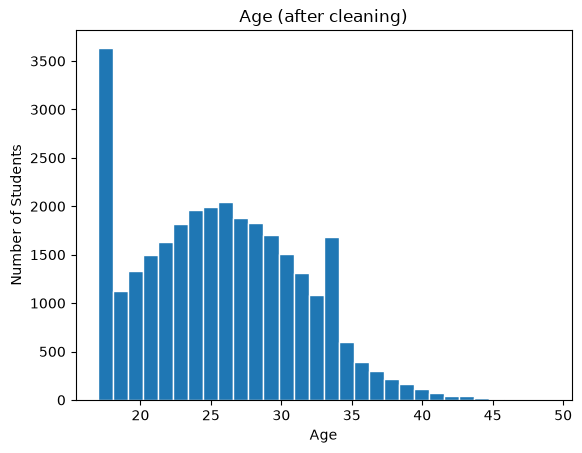

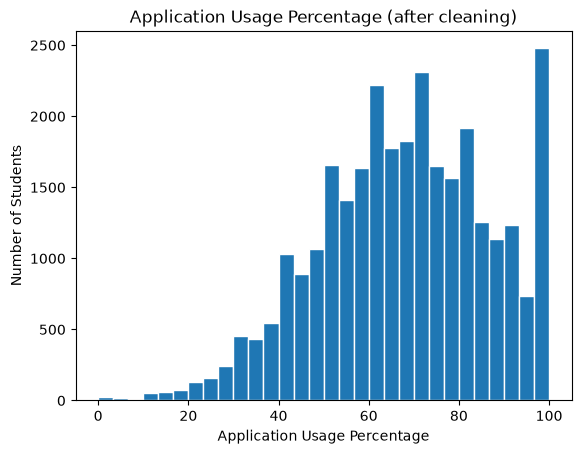

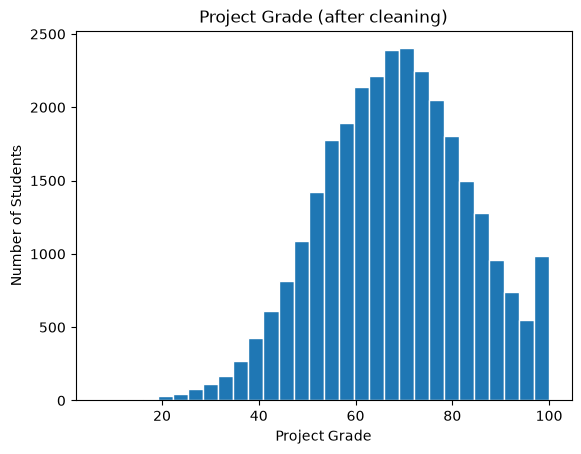

In [112]:
plt.hist(df_etl_clean["Age"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Age (after cleaning)")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()
plt.hist(df_etl_clean["App_Usage_Percentage"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Application Usage Percentage (after cleaning)")
plt.xlabel("Application Usage Percentage")
plt.ylabel("Number of Students")
plt.show()
plt.hist(df_etl_clean["Project_Grade"].dropna(), bins=30, edgecolor="white", linewidth=1)
plt.title("Project Grade (after cleaning)")
plt.xlabel("Project Grade")
plt.ylabel("Number of Students")
plt.show()

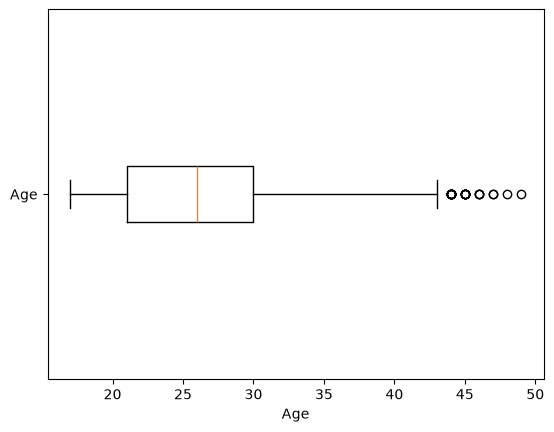

In [113]:
plt.boxplot(df_etl_clean["Age"].dropna(), orientation="horizontal", tick_labels=["Age"])
plt.xlabel("Age")
plt.show()

In [114]:
def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

age_flag = iqr_flag(df_etl_clean["age"])
height_flag = iqr_flag(df_etl_clean["height"])
weight_flag = iqr_flag(df_etl_clean["weight"])
demographic_flags = age_flag | height_flag | weight_flag

print(
    df_etl_clean.loc[
        demographic_flags,
        ["age", "sex", "height", "weight", "class"]
    ].sort_values(["age", "height", "weight"]).to_string()
)

# Heart rate is checked separately with a z-score
mean_hr = df_etl_clean["heart_rate"].mean()
std_hr = df_etl_clean["heart_rate"].std()
z_hr = (df_etl_clean["heart_rate"] - mean_hr) / std_hr

print("Heart-rate values with |z| > 3:")
print(df_etl_clean.loc[z_hr.abs() > 3, ["age", "sex", "heart_rate", "class"]])

KeyError: 'age'

In [ ]:
print(
    df_etl_clean.loc[
        (df_etl_clean["age"] == 75) &
        (df_etl_clean["sex"] == 0) &
        (df_etl_clean["height"] == 190) &
        (df_etl_clean["weight"] == 80)
    ].to_string()
)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_etl_clean["height"].dropna(), tick_labels=["Height"])
axes[0].set_title("Height"); axes[0].set_ylabel("cm")
axes[1].boxplot(df_etl_clean["heart_rate"].dropna(), tick_labels=["Heart rate"])
axes[1].set_title("Heart rate"); axes[1].set_ylabel("bpm")
axes[2].boxplot(df_etl_clean["weight"].dropna(), tick_labels=["Weight"])
axes[2].set_title("Weight"); axes[2].set_ylabel("kg")
plt.suptitle("Cleaned data before optional capping")
plt.show()

In [ ]:
df_sensitivity = df_etl_clean.copy(deep=True)
df_sensitivity["height_capped"] = df_sensitivity["height"].clip(
    lower=df_sensitivity["height"].quantile(0.01)
)
df_sensitivity["heart_rate_capped"] = df_sensitivity["heart_rate"].clip(
    lower=df_sensitivity["heart_rate"].quantile(0.01),
    upper=df_sensitivity["heart_rate"].quantile(0.99)
)
df_sensitivity["weight_capped"] = df_sensitivity["weight"].clip(
    upper=df_sensitivity["weight"].quantile(0.99)
)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_sensitivity["height_capped"].dropna(), tick_labels=["Height"])
axes[0].set_title("Height (sensitivity-capped)"); axes[0].set_ylabel("cm")
axes[1].boxplot(df_sensitivity["heart_rate_capped"].dropna(), tick_labels=["Heart rate"])
axes[1].set_title("Heart rate (capped)"); axes[1].set_ylabel("bpm")
axes[2].boxplot(df_sensitivity["weight_capped"].dropna(), tick_labels=["Weight"])
axes[2].set_title("Weight (capped)"); axes[2].set_ylabel("kg")
plt.suptitle("Optional sensitivity-only capped view")
plt.show()

In [ ]:
rate = df_etl_clean.groupby("sex", observed=False)["arrhythmia_present"].mean()
print(rate)
sex_labels = {0: "Male", 1: "Female"}
labels = [sex_labels[int(value)] for value in rate.index]
plt.bar(labels, rate.values)
plt.xlabel("Sex")
plt.ylabel("Proportion with arrhythmia")
plt.title("Arrhythmia rate by sex")
plt.show()          # Figure 13 is what you'll see

In [ ]:
import numpy as np

num_cols = ["age", "height", "weight", "qrs_duration", "pr_interval", "qt_interval",
    "heart_rate"]
corr_matrix = df_etl_clean[num_cols].corr()
print(corr_matrix.round(2))

# Find the strongest non-diagonal linear association
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()
print(
    "Strongest absolute correlation:",
    strongest_pair,
    round(corr_matrix.loc[strongest_pair[0], strongest_pair[1]], 2)
)
plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation between 7 of 279 input features")
plt.show()          # Figure 14 is what you'll see

In [ ]:
class_names = {
    1: "Normal", 2: "Ischemic changes (CAD)", 3: "Old Ant. MI", 4: "Old Inf. MI",
    5: "Sinus tachycardia", 6: "Sinus bradycardia", 7: "PVC", 8: "Supraventricular PC",
    9: "Left bundle branch block", 10: "Right bundle branch block",
    11: "1st degree AV block", 12: "2nd degree AV block", 13: "3rd degree AV block",
    14: "Left vent. hypertrophy", 15: "Atrial fib./flutter", 16: "Other",
}
pqrst_cols = ["p_interval", "qrs_duration", "pr_interval", "qt_interval", "t_interval",
    "heart_rate"]
class_counts = df_etl_clean["class"].value_counts().sort_index()
print("Patients per class:")
print(class_counts)
profile = df_etl_clean.groupby("class")[pqrst_cols].mean()
print("Mean profile per class:")
print(profile.round(1))
# standardise each column so differing scales (ms vs bpm) do not dominate the color map
profile_z = (profile - profile.mean()) / profile.std()
row_labels = [class_names[int(c)] for c in profile_z.index]
plt.imshow(profile_z.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
plt.xticks(range(len(pqrst_cols)), pqrst_cols, rotation=45, ha="right")
plt.yticks(range(len(profile_z)), row_labels)
plt.colorbar(label="Standardised mean (per column)")
plt.title("PQRST + heart rate profile, by arrhythmia type")
plt.show()

In [ ]:
miss = df_copy.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0] * 100
plt.barh(miss.index.astype(str), miss.values)
plt.xlabel("% missing")
plt.title("Missing values in the raw data")
plt.show()

In [ ]:
order = sorted(df_etl_clean["class"].unique())
x_pos = df_etl_clean["class"].map({c: i for i, c in enumerate(order)})
plt.scatter(x_pos, df_etl_clean["heart_rate"], alpha=0.4)
means = df_etl_clean.groupby("class")["heart_rate"].mean()
print("Mean heart rate by class:")
print(means.sort_values())
plt.scatter(range(len(order)), [means[c] for c in order], color="red", marker="D",
    label="Mean per type")
plt.xticks(range(len(order)), [class_names[c] for c in order], rotation=45, ha="right")
plt.xlabel("Arrhythmia type"); plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate by arrhythmia type")
plt.legend()
plt.show()

In [ ]:
from matplotlib.lines import Line2D

colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
plt.scatter(df_etl_clean["height"], df_etl_clean["weight"], c=colors, alpha=0.5)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight, by diagnosis")
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="teal", markersize=8, label="No arrhythmia"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="orange", markersize=8, label="Arrhythmia present"),
]
plt.legend(handles=legend_handles)
plt.show()

In [ ]:
jitter = df_etl_clean["arrhythmia_present"].astype(int) + np.random.uniform(-0.08, 0.08,
    len(df_etl_clean))
colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
plt.scatter(df_etl_clean["age"], jitter, c=colors, alpha=0.5)
plt.yticks([0, 1], ["No", "Yes"])
plt.xlabel("Age")
plt.ylabel("arrhythmia_present")
plt.title("Age vs arrhythmia_present")
plt.show()          # y-axis labels (No/Yes) already identify the two colours here

In [ ]:
colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
cols = ["height", "weight", "qt_interval", "heart_rate"]
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(df_etl_clean[c1].dropna(), bins=20)
        else:
            ax.scatter(df_etl_clean[c2], df_etl_clean[c1], s=4, alpha=0.35, c=colors)
        if i == 3:
            ax.set_xlabel(c2)
        if j == 0:
            ax.set_ylabel(c1)
plt.tight_layout()
from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color="teal", label="No arrhythmia"),
    Patch(color="orange", label="Arrhythmia present"),
], loc="upper right")
plt.show()

In [ ]:
from scipy import stats

a = df_etl_clean.loc[df_etl_clean["arrhythmia_present"], "heart_rate"]
b = df_etl_clean.loc[~df_etl_clean["arrhythmia_present"], "heart_rate"]
t, p = stats.ttest_ind(a, b, equal_var=False)

print("Mean with arrhythmia:", a.mean())
print("Mean without arrhythmia:", b.mean())

print(f"t = {t:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Reject H0: the mean heart rates differ significantly.")
else:
    print("Fail to reject H0: no significant mean difference was detected.")

In [ ]:
from scipy import stats

table = pd.crosstab(
    df_etl_clean["sex"],
    df_etl_clean["arrhythmia_present"]
)
print(table)
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"chi2 = {chi2:.2f}, p = {p:.6f}")
if p < 0.05:
    print("Reject H0: sex and diagnosis are associated in this sample.")
else:
    print("Fail to reject H0: no significant association was detected.")

In [ ]:
# Check duplicate Student_ID values
print("Duplicate Student_IDs:", df["Student_ID"].duplicated().sum())

Duplicate Student_IDs: 1


In [ ]:
# Display all rows that share a duplicated Student_ID
# keep=False shows both copies of the duplicated record
df[df["Student_ID"].duplicated(keep=False)]

,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,1/06/2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,1/06/2024,Scholarship,No,No,1740,49,3,4,3.5,Completed


In [ ]:
# Create a cleaned copy and remove completely identical duplicate rows
df_clean = df.drop_duplicates().copy()

In [ ]:
# Compare the number of rows before and after duplicate removal
print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (30001, 40)
After: (30000, 40)


In [ ]:
# Check that there are no completely duplicated rows remaining
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

# Check that there are no duplicated Student_ID values remaining
print(
    "Duplicate Student_IDs:",
    df_clean["Student_ID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Student_IDs: 0


In [ ]:
# Show summary statistics for the Age column
# This helps us inspect the age range before deciding
# whether my teammate's current age-cleaning rule is justified
df_copy["Age"].describe()

count    30001.000000
mean        25.708410
std          5.649464
min         17.000000
25%         21.000000
50%         26.000000
75%         30.000000
max        170.000000
Name: Age, dtype: float64

In [ ]:
# Show all records where Age is greater than 60
# This lets us inspect the unusual ages before deciding what to clean
df_copy.loc[
    df_copy["Age"] > 60,
    ["Student_ID", "Name", "Age"]
].sort_values("Age")

,Student_ID,Name,Age
2,STU100001,Arjun Nair,170


In [ ]:
# Verify that the confirmed age error was corrected
# Shows STU100001 with Age = 17
df_clean_preview.loc[
    df_clean_preview["Student_ID"] == "STU100001",
    ["Student_ID", "Name", "Age"]
]

,Student_ID,Name,Age
1,STU100001,Arjun Nair,17


In [ ]:
# Check the total number of assignments for each student
# This helps us see whether submitted + missed is consistent across the dataset
assignment_total = (
    df_copy["Assignments_Submitted"]
    + df_copy["Assignments_Missed"]
)

# Show how many students have each total
print(assignment_total.value_counts().sort_index())

9      3051
10    26950
Name: count, dtype: int64


In [ ]:
# Compare the total number of assignments across each course
# This helps us check whether some courses genuinely have 9 assignments
# while other courses have 10

assignment_by_course = pd.crosstab(
    df_copy["Course_ID"],
    assignment_total
)

print(assignment_by_course)

col_0       9     10
Course_ID           
C101       478  4604
C102       466  4104
C103       363  3415
C104       401  3355
C105       272  2280
C106       335  3041
C107       340  2717
C108       396  3434


In [ ]:
# Show the combinations of assignments submitted and missed
# This helps us see exactly how the total of 9 or 10 is being formed

assignment_combinations = (
    df_copy
    .groupby(["Assignments_Submitted", "Assignments_Missed"])
    .size()
    .reset_index(name="Count")
)

print(assignment_combinations)

    Assignments_Submitted  Assignments_Missed  Count
0                       0                   9      8
1                       0                  10     73
2                       1                   8     37
3                       1                   9    501
4                       2                   7    212
5                       2                   8   1691
6                       3                   6    449
7                       3                   7   3782
8                       4                   5    654
9                       4                   6   5766
10                      5                   4    704
11                      5                   5   6179
12                      6                   3    528
13                      6                   4   4802
14                      7                   2    311
15                      7                   3   2786
16                      8                   1    129
17                      8                   2 

NOTE: Assignment totals of 9 and 10 occur across multiple courses and also appear in the original source dataset. Because there is no evidence identifying a missing assignment value, these records were retained unchanged.

In [ ]:
# Find all categorical/text columns in the untouched dataset
# These columns will be checked for inconsistent categories
categorical_cols = df_copy.select_dtypes(
    include=["object", "string"]
).columns

# Display the categorical column names
print(categorical_cols.tolist())

['Student_ID', 'Name', 'Gender', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Course_Name', 'Category', 'Course_Level', 'Enrollment_Date', 'Payment_Mode', 'Fee_Paid', 'Discount_Used', 'Completed']


In [ ]:
# Select categorical columns that should contain a limited number of categories
# Student_ID and Name are excluded because they contain many unique values
category_check_cols = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Course_Name",
    "Category",
    "Course_Level",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
    "Completed"
]

# Display the unique values in each categorical column
for col in category_check_cols:
    print(f"\n{col}:")
    print(df_copy[col].unique())


Gender:
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

Education_Level:
<StringArray>
['Diploma', 'Bachelor', 'Master', 'HighSchool', 'PhD']
Length: 5, dtype: str

Employment_Status:
<StringArray>
['Student', 'Employed', 'Self-Employed', 'Unemployed']
Length: 4, dtype: str

City:
<StringArray>
[   'Indore',     'Delhi',   'Chennai',     'Surat',   'Lucknow',    'Jaipur',
 'Hyderabad',    'Nagpur',   'Kolkata', 'Ahmedabad',      'Pune',    'Mumbai',
 'Bengaluru',    'Bhopal',  'Vadodara']
Length: 15, dtype: str

Device_Type:
<StringArray>
['Laptop', 'Mobile', 'Tablet']
Length: 3, dtype: str

Internet_Connection_Quality:
<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

Course_ID:
<StringArray>
['C102', 'C106', 'C101', 'C105', 'C103', 'C104', 'C107', 'C108']
Length: 8, dtype: str

Course_Name:
<StringArray>
[   'Data Analysis with Python',         'Machine Learning A-Z',
                'Python Basics',    'UI/UX Design Fundamentals',
           'Introduct

In [ ]:
# Check categorical columns for hidden inconsistencies
# Example: "Male", "male", or " Male " would be treated as possible duplicates
for col in category_check_cols:

    # Count categories exactly as they currently appear
    original_count = df_copy[col].nunique(dropna=False)

    # Count categories after removing spaces and ignoring capitalisation
    cleaned_count = (
        df_copy[col]
        .astype("string")
        .str.strip()
        .str.lower()
        .nunique(dropna=False)
    )

    # Only display a result if inconsistent formatting is found
    if original_count != cleaned_count:
        print(
            col,
            "- possible inconsistent categories:",
            original_count,
            "original vs",
            cleaned_count,
            "standardised"
        )

In [ ]:
# List the payment-related columns we want to inspect
payment_cols = [
    "Payment_Mode",
    "Fee_Paid",
    "Payment_Amount",
    "Discount_Used"
]

# Show the values/counts in each payment column
# This helps us understand how the payment data is structured
for col in payment_cols:
    print(f"\n{col}:")
    print(df_copy[col].value_counts(dropna=False))


Payment_Mode:
Payment_Mode
UPI            8969
Free           5798
Credit Card    4607
Debit Card     4500
NetBanking     3161
Scholarship    2966
Name: count, dtype: int64

Fee_Paid:
Fee_Paid
Yes    21237
No      8764
Name: count, dtype: int64

Payment_Amount:
Payment_Amount
0       5798
3825      22
3482      19
4389      18
4277      17
        ... 
1210       1
6571       1
2062       1
424        1
568        1
Name: count, Length: 5919, dtype: int64

Discount_Used:
Discount_Used
No     24105
Yes     5896
Name: count, dtype: int64


In [ ]:
# Compare Payment_Mode with Fee_Paid
# This checks whether each payment method has the expected Yes/No payment status
payment_fee_check = pd.crosstab(
    df_copy["Payment_Mode"],
    df_copy["Fee_Paid"]
)

print(payment_fee_check)

Fee_Paid        No   Yes
Payment_Mode            
Credit Card      0  4607
Debit Card       0  4500
Free          5798     0
NetBanking       0  3161
Scholarship   2966     0
UPI              0  8969


In [ ]:
# Check whether each payment mode has a zero or non-zero payment amount
# This helps detect cases such as a Free course having a positive payment amount

payment_amount_check = pd.crosstab(
    df_copy["Payment_Mode"],
    df_copy["Payment_Amount"] == 0
)

print(payment_amount_check)

Payment_Amount  False  True 
Payment_Mode                
Credit Card      4607      0
Debit Card       4500      0
Free                0   5798
NetBanking       3161      0
Scholarship      2966      0
UPI              8969      0


In [ ]:
# Show summary statistics for Scholarship payment amounts
# This helps us understand what Payment_Amount represents for scholarship students
df_copy.loc[
    df_copy["Payment_Mode"] == "Scholarship",
    "Payment_Amount"
].describe()

count    2966.000000
mean     1260.537761
std       671.801769
min       166.000000
25%       698.250000
50%      1203.000000
75%      1711.750000
max      3238.000000
Name: Payment_Amount, dtype: float64

In [ ]:
# Compare payment method with whether a discount was used
# This helps us check how discounts are recorded for each payment type
payment_discount_check = pd.crosstab(
    df_copy["Payment_Mode"],
    df_copy["Discount_Used"]
)

print(payment_discount_check)

Discount_Used    No   Yes
Payment_Mode             
Credit Card    3717   890
Debit Card     3626   874
Free           4651  1147
NetBanking     2517   644
Scholarship    2376   590
UPI            7218  1751


In [ ]:
# Inspect Free-course records where Discount_Used is Yes
# This checks whether their payment amount is still correctly recorded as 0
free_discount = df_copy[
    (df_copy["Payment_Mode"] == "Free")
    & (df_copy["Discount_Used"] == "Yes")
]

# Show how many such records exist
print("Free courses with discount:", len(free_discount))

# Show the payment amounts for these records
print(free_discount["Payment_Amount"].value_counts())

Free courses with discount: 1147
Payment_Amount
0    1147
Name: count, dtype: int64


In [ ]:
# Check the range of Payment_Amount
# Payment amounts should not be negative
print("Minimum payment amount:", df_copy["Payment_Amount"].min())
print("Maximum payment amount:", df_copy["Payment_Amount"].max())

# Count any negative payment amounts
print(
    "Negative payment amounts:",
    (df_copy["Payment_Amount"] < 0).sum()
)

Minimum payment amount: 0
Maximum payment amount: 7149
Negative payment amounts: 0


NOTE: Scholarship records show Fee_Paid = No with a positive Payment_Amount. This pattern also appears in the original source dataset, so it was retained. Fee_Paid = No is interpreted as the student not personally paying the fee, while Payment_Amount may represent the amount covered by the scholarship.

In [ ]:
# Check how many different Course_Name values are linked to each Course_ID
course_id_check = (
    df_copy
    .groupby("Course_ID")["Course_Name"]
    .nunique()
    .sort_values(ascending=False)
)

print(course_id_check)

Course_ID
C101    1
C102    1
C103    1
C104    1
C105    1
C106    1
C107    1
C108    1
Name: Course_Name, dtype: int64


In [ ]:
# Find all numerical columns in the raw dataset
numerical_cols = df_copy.select_dtypes(include="number").columns

# Check the minimum value and number of negative values in each numerical column
for col in numerical_cols:
    minimum_value = df_copy[col].min()
    negative_count = (df_copy[col] < 0).sum()

    print(
        f"{col}: "
        f"minimum = {minimum_value}, "
        f"negative values = {negative_count}"
    )

Age: minimum = 17, negative values = 0
Course_Duration_Days: minimum = 25, negative values = 0
Instructor_Rating: minimum = 4.1, negative values = 0
Login_Frequency: minimum = 0, negative values = 0
Average_Session_Duration_Min: minimum = 5, negative values = 0
Video_Completion_Rate: minimum = 5.0, negative values = 0
Discussion_Participation: minimum = 0, negative values = 0
Time_Spent_Hours: minimum = 0.5, negative values = 0
Days_Since_Last_Login: minimum = 0, negative values = 0
Notifications_Checked: minimum = 0, negative values = 0
Peer_Interaction_Score: minimum = 0.0, negative values = 0
Assignments_Submitted: minimum = 0, negative values = 0
Assignments_Missed: minimum = 0, negative values = 0
Quiz_Attempts: minimum = 0, negative values = 0
Quiz_Score_Avg: minimum = 19.6, negative values = 0
Project_Grade: minimum = 6.8, negative values = 0
Progress_Percentage: minimum = 9.7, negative values = 0
Rewatch_Count: minimum = 0, negative values = 0
Payment_Amount: minimum = 0, negat

In [ ]:
# Check the minimum and maximum values for the rating columns
# Both ratings should stay between their valid limits and must not exceed 5

for col in ["Instructor_Rating", "Satisfaction_Rating"]:
    print(
        f"{col}: "
        f"minimum = {df_copy[col].min()}, "
        f"maximum = {df_copy[col].max()}, "
        f"values above 5 = {(df_copy[col] > 5).sum()}"
    )

Instructor_Rating: minimum = 4.1, maximum = 4.7, values above 5 = 0
Satisfaction_Rating: minimum = 1.0, maximum = 5.0, values above 5 = 0


In [ ]:
# List the columns that represent percentages/rates
percentage_cols = [
    "Video_Completion_Rate",
    "Progress_Percentage",
    "App_Usage_Percentage"
]

# Check the minimum, maximum, and how many values exceed 100
for col in percentage_cols:
    print(
        f"{col}: "
        f"minimum = {df_copy[col].min()}, "
        f"maximum = {df_copy[col].max()}, "
        f"values above 100 = {(df_copy[col] > 100).sum()}"
    )

Video_Completion_Rate: minimum = 5.0, maximum = 99.9, values above 100 = 0
Progress_Percentage: minimum = 9.7, maximum = 97.4, values above 100 = 0
App_Usage_Percentage: minimum = 0, maximum = 100, values above 100 = 0


In [ ]:
# Show which dataframe variables currently exist
print([
    name
    for name in globals()
    if name.startswith("df")
])

['df', 'df_copy', 'df_clean_preview', 'df_etl_clean', 'df_elt_raw', 'df_elt_clean']


In [ ]:
# Confirm df_copy is loaded correctly
print(df_copy.shape)

(30001, 40)


In [ ]:
# Check the valid responses in binary text columns
binary_cols = [
    "Fee_Paid",
    "Discount_Used",
    "Completed"
]

for col in binary_cols:
    print(f"\n{col}:")
    print(df_copy[col].value_counts(dropna=False))


Fee_Paid:
Fee_Paid
Yes    21237
No      8764
Name: count, dtype: int64

Discount_Used:
Discount_Used
No     24105
Yes     5896
Name: count, dtype: int64

Completed:
Completed
Not Completed    15208
Completed        14793
Name: count, dtype: int64


In [ ]:
# Check whether a Country column exists in the dataset
print("Country column exists:", "Country" in df_copy.columns)

# Show all unique course names
print("\nCourse Names:")
print(sorted(df_copy["Course_Name"].dropna().unique()))

Country column exists: False

Course Names:
['Data Analysis with Python', 'Digital Marketing Essentials', 'Excel for Business', 'Introduction to AI', 'Machine Learning A-Z', 'Python Basics', 'Statistics for Data Science', 'UI/UX Design Fundamentals']


In [ ]:
# Compare every Course_Name with every other Course_Name
# This helps find names that are very similar and may be accidental misspellings

from difflib import SequenceMatcher

course_names = df_copy["Course_Name"].dropna().unique()

for i in range(len(course_names)):
    for j in range(i + 1, len(course_names)):

        # Calculate how similar the two course names are
        similarity = SequenceMatcher(
            None,
            course_names[i].lower(),
            course_names[j].lower()
        ).ratio()

        # Only display pairs that are at least 80% similar
        if similarity >= 0.80:
            print(
                course_names[i],
                "<->",
                course_names[j],
                "similarity =",
                round(similarity, 2)
            )

In [ ]:
# Check the number of missing values in every column
missing_values = df_copy.isna().sum()

# Show only columns that actually contain missing values
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [ ]:
# Check the data type of every column
print(df_copy.dtypes)

# Specifically inspect Enrollment_Date
print("\nEnrollment_Date data type:")
print(df_copy["Enrollment_Date"].dtype)

# Show a few Enrollment_Date values
print("\nExample Enrollment_Date values:")
print(df_copy["Enrollment_Date"].head())

Student_ID                          str
Name                                str
Gender                              str
Age                               int64
Education_Level                     str
Employment_Status                   str
City                                str
Device_Type                         str
Internet_Connection_Quality         str
Course_ID                           str
Course_Name                         str
Category                            str
Course_Level                        str
Course_Duration_Days              int64
Instructor_Rating               float64
Login_Frequency                   int64
Average_Session_Duration_Min      int64
Video_Completion_Rate           float64
Discussion_Participation          int64
Time_Spent_Hours                float64
Days_Since_Last_Login             int64
Notifications_Checked             int64
Peer_Interaction_Score          float64
Assignments_Submitted             int64
Assignments_Missed                int64


In [ ]:
# Convert Enrollment_Date temporarily for inspection only
# dayfirst=True because the dataset uses DD/MM/YYYY
enrollment_date_check = pd.to_datetime(
    df_copy["Enrollment_Date"],
    dayfirst=True,
    errors="coerce"
)

# Count dates that could not be converted
print(
    "Invalid Enrollment_Date values:",
    enrollment_date_check.isna().sum()
)

# Show the earliest and latest enrollment dates
print("Earliest enrollment date:", enrollment_date_check.min())
print("Latest enrollment date:", enrollment_date_check.max())

Invalid Enrollment_Date values: 0
Earliest enrollment date: 2023-10-17 00:00:00
Latest enrollment date: 2025-10-06 00:00:00


In [ ]:
# Show the minimum and maximum for every numerical column
# This helps identify values that may need further investigation

numerical_ranges = df_copy.select_dtypes(include="number").agg(["min", "max"]).T

print(numerical_ranges)

                               min     max
Age                           17.0   170.0
Course_Duration_Days          25.0    90.0
Instructor_Rating              4.1     4.7
Login_Frequency                0.0    15.0
Average_Session_Duration_Min   5.0    76.0
Video_Completion_Rate          5.0    99.9
Discussion_Participation       0.0    12.0
Time_Spent_Hours               0.5    25.6
Days_Since_Last_Login          0.0    99.0
Notifications_Checked          0.0    18.0
Peer_Interaction_Score         0.0    10.0
Assignments_Submitted          0.0    10.0
Assignments_Missed             0.0    10.0
Quiz_Attempts                  0.0    16.0
Quiz_Score_Avg                19.6   100.0
Project_Grade                  6.8   100.0
Progress_Percentage            9.7    97.4
Rewatch_Count                  0.0    12.0
Payment_Amount                 0.0  7149.0
App_Usage_Percentage           0.0   100.0
Reminder_Emails_Clicked        0.0    13.0
Support_Tickets_Raised         0.0     7.0
Satisfactio

In [ ]:
# Find records where App_Usage_Percentage is exactly 100
app_usage_100 = df_copy[
    df_copy["App_Usage_Percentage"] == 100
]

# Count how many records have exactly 100%
print("Records with App_Usage_Percentage = 100:", len(app_usage_100))

# Show the student IDs and usage percentage
print(
    app_usage_100[
        ["Student_ID", "App_Usage_Percentage"]
    ].head(20)
)

Records with App_Usage_Percentage = 100: 1871
    Student_ID  App_Usage_Percentage
13   STU100012                   100
28   STU100027                   100
44   STU100043                   100
48   STU100047                   100
49   STU100048                   100
67   STU100066                   100
70   STU100069                   100
82   STU100081                   100
98   STU100097                   100
126  STU100125                   100
144  STU100143                   100
169  STU100168                   100
175  STU100174                   100
178  STU100177                   100
184  STU100183                   100
188  STU100187                   100
219  STU100218                   100
226  STU100225                   100
283  STU100282                   100
292  STU100291                   100
